In [ ]:
import pandas as pd
df = pd.read_csv('/content/Credit_card (1).csv')
df

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,1,0,0,0,NaN,2
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,-586,1,1,1,0,NaN,2
3,5009749,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1543,5028645,F,N,Y,0,NaN,Commercial associate,Higher education,Married,House / apartment,-11957.0,-2182,1,0,0,0,Managers,2
1544,5023655,F,N,N,0,225000.0,Commercial associate,Incomplete higher,Single / not married,House / apartment,-10229.0,-1209,1,0,0,0,Accountants,1
1545,5115992,M,Y,Y,2,180000.0,Working,Higher education,Married,House / apartment,-13174.0,-2477,1,0,0,0,Managers,4
1546,5118219,M,Y,N,0,270000.0,Working,Secondary / secondary special,Civil marriage,House / apartment,-15292.0,-645,1,1,1,0,Drivers,2


In [ ]:
label = pd.read_csv('/content/Credit_card_label.csv')
label

,Ind_ID,label
0,5008827,1
1,5009744,1
2,5009746,1
3,5009749,1
4,5009752,1
...,...,...
1543,5028645,0
1544,5023655,0
1545,5115992,0
1546,5118219,0


In [ ]:
df = df.join(label.set_index('Ind_ID'), on = 'Ind_ID')

In [ ]:
df.shape

(1548, 19)

In [ ]:
df.columns

Index(['Ind_ID', 'GENDER', 'Car_Owner', 'Propert_Owner', 'CHILDREN',
       'Annual_income', 'Type_Income', 'EDUCATION', 'Marital_status',
       'Housing_type', 'Birthday_count', 'Employed_days', 'Mobile_phone',
       'Work_Phone', 'Phone', 'EMAIL_ID', 'Type_Occupation', 'Family_Members',
       'label'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Ind_ID           1548 non-null   int64  
 1   GENDER           1541 non-null   object 
 2   Car_Owner        1548 non-null   object 
 3   Propert_Owner    1548 non-null   object 
 4   CHILDREN         1548 non-null   int64  
 5   Annual_income    1525 non-null   float64
 6   Type_Income      1548 non-null   object 
 7   EDUCATION        1548 non-null   object 
 8   Marital_status   1548 non-null   object 
 9   Housing_type     1548 non-null   object 
 10  Birthday_count   1526 non-null   float64
 11  Employed_days    1548 non-null   int64  
 12  Mobile_phone     1548 non-null   int64  
 13  Work_Phone       1548 non-null   int64  
 14  Phone            1548 non-null   int64  
 15  EMAIL_ID         1548 non-null   int64  
 16  Type_Occupation  1060 non-null   object 
 17  Family_Members

In [ ]:
df.isnull().sum()

,0
Ind_ID,0
GENDER,7
Car_Owner,0
Propert_Owner,0
CHILDREN,0
Annual_income,23
Type_Income,0
EDUCATION,0
Marital_status,0
Housing_type,0


In [ ]:
df['Housing_type'].value_counts()

,count
Housing_type,
House / apartment,1380
With parents,80
Municipal apartment,53
Rented apartment,21
Office apartment,9
Co-op apartment,5


In [ ]:
df = df.drop(['Ind_ID', 'GENDER', 'EDUCATION', 'Marital_status', 'Mobile_phone', 'Work_Phone', 'Phone', 'EMAIL_ID', 'Type_Occupation', 'CHILDREN'], axis = 1)

In [ ]:
df.describe().round(2)

,Annual_income,Birthday_count,Employed_days,Family_Members,label
count,1525.00,1526.00,1548.00,1548.00,1548.00
mean,191399.33,-16040.34,59364.69,2.16,0.11
std,113253.00,4229.50,137808.06,0.95,0.32
min,33750.00,-24946.00,-14887.00,1.00,0.00
25%,121500.00,-19553.00,-3174.50,2.00,0.00
50%,166500.00,-15661.50,-1565.00,2.00,0.00
75%,225000.00,-12417.00,-431.75,3.00,0.00
max,1575000.00,-7705.00,365243.00,15.00,1.00


In [ ]:
df['Monthly_Income'] = df['Annual_income'] / 12.0
df

,Car_Owner,Propert_Owner,Annual_income,Type_Income,Housing_type,Birthday_count,Employed_days,Family_Members,label,Monthly_Income
0,Y,Y,180000.0,Pensioner,House / apartment,-18772.0,365243,2,1,15000.0
1,Y,N,315000.0,Commercial associate,House / apartment,-13557.0,-586,2,1,26250.0
2,Y,N,315000.0,Commercial associate,House / apartment,NaN,-586,2,1,26250.0
3,Y,N,NaN,Commercial associate,House / apartment,-13557.0,-586,2,1,NaN
4,Y,N,315000.0,Commercial associate,House / apartment,-13557.0,-586,2,1,26250.0
...,...,...,...,...,...,...,...,...,...,...
1543,N,Y,NaN,Commercial associate,House / apartment,-11957.0,-2182,2,0,NaN
1544,N,N,225000.0,Commercial associate,House / apartment,-10229.0,-1209,1,0,18750.0
1545,Y,Y,180000.0,Working,House / apartment,-13174.0,-2477,4,0,15000.0
1546,Y,N,270000.0,Working,House / apartment,-15292.0,-645,2,0,22500.0


In [ ]:
df.drop('Annual_income', axis = 1, inplace = True)

In [ ]:
df['Age'] = (df['Birthday_count'] // 365).abs()


In [ ]:
df

,Car_Owner,Propert_Owner,Type_Income,Housing_type,Birthday_count,Employed_days,Family_Members,label,Monthly_Income,Age
0,Y,Y,Pensioner,House / apartment,-18772.0,365243,2,1,15000.0,52.0
1,Y,N,Commercial associate,House / apartment,-13557.0,-586,2,1,26250.0,38.0
2,Y,N,Commercial associate,House / apartment,NaN,-586,2,1,26250.0,NaN
3,Y,N,Commercial associate,House / apartment,-13557.0,-586,2,1,NaN,38.0
4,Y,N,Commercial associate,House / apartment,-13557.0,-586,2,1,26250.0,38.0
...,...,...,...,...,...,...,...,...,...,...
1543,N,Y,Commercial associate,House / apartment,-11957.0,-2182,2,0,NaN,33.0
1544,N,N,Commercial associate,House / apartment,-10229.0,-1209,1,0,18750.0,29.0
1545,Y,Y,Working,House / apartment,-13174.0,-2477,4,0,15000.0,37.0
1546,Y,N,Working,House / apartment,-15292.0,-645,2,0,22500.0,42.0


In [ ]:
df['Expericence(M)'] = (df['Employed_days'] // 30).abs()

In [ ]:
df.drop(['Birthday_count', 'Employed_days'], axis = 1, inplace = True)

In [ ]:
df.describe()

,Family_Members,label,Monthly_Income,Age,Expericence(M)
count,1548.000000,1548.000000,1525.000000,1526.000000,1548.000000
mean,2.161499,0.113049,15949.943852,44.436435,2126.885013
std,0.947772,0.316755,9437.749805,11.585840,4526.566962
min,1.000000,0.000000,2812.500000,22.000000,3.000000
25%,2.000000,0.000000,10125.000000,35.000000,39.000000
50%,2.000000,0.000000,13875.000000,43.000000,83.000000
75%,3.000000,0.000000,18750.000000,54.000000,202.250000
max,15.000000,1.000000,131250.000000,69.000000,12174.000000


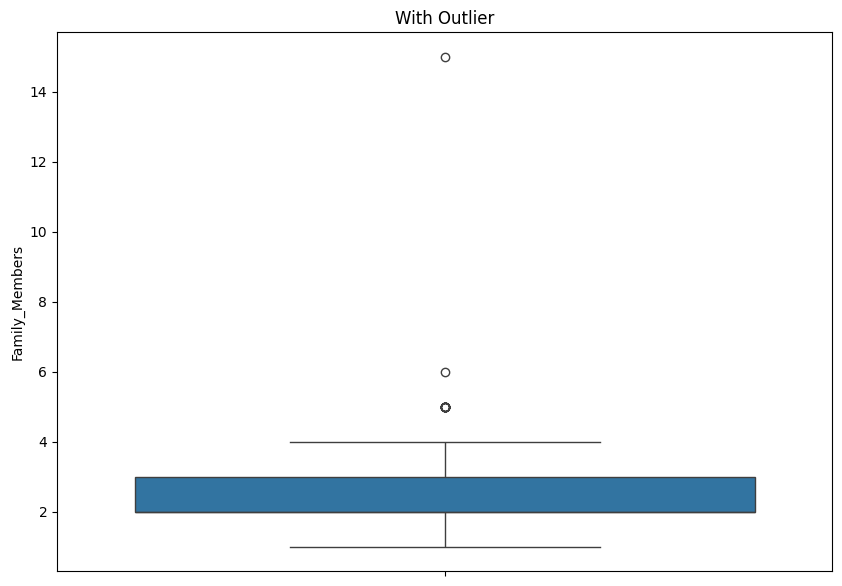

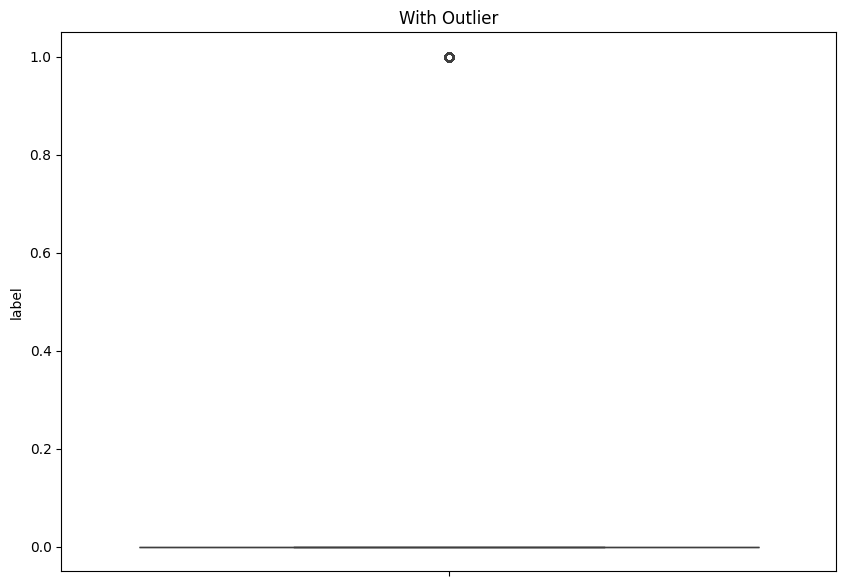

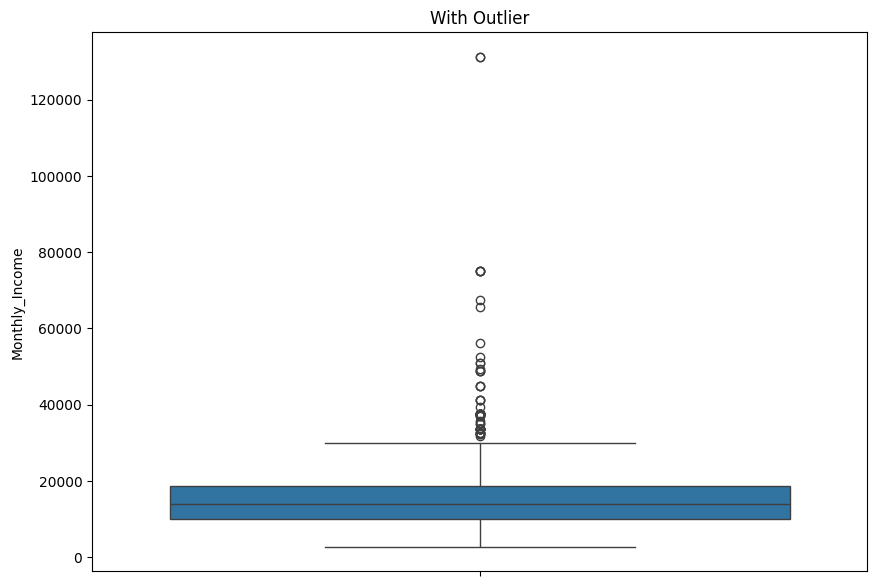

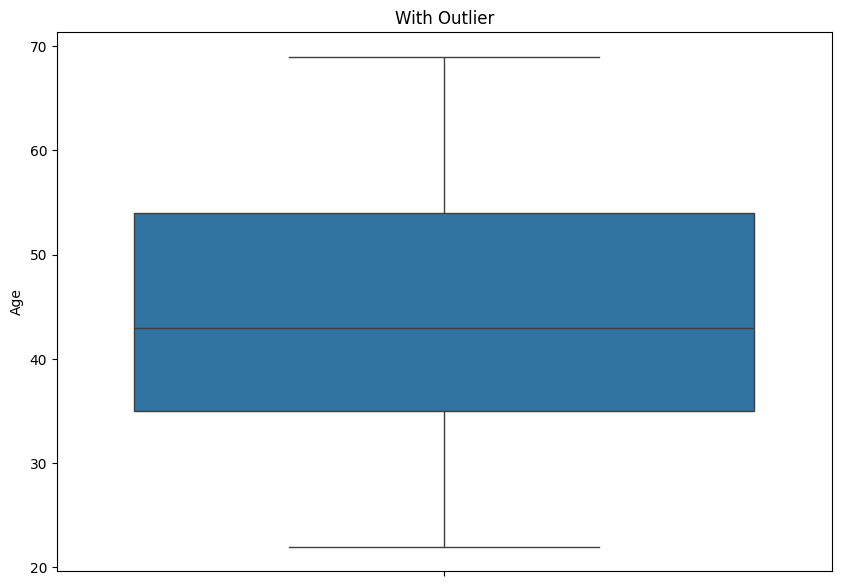

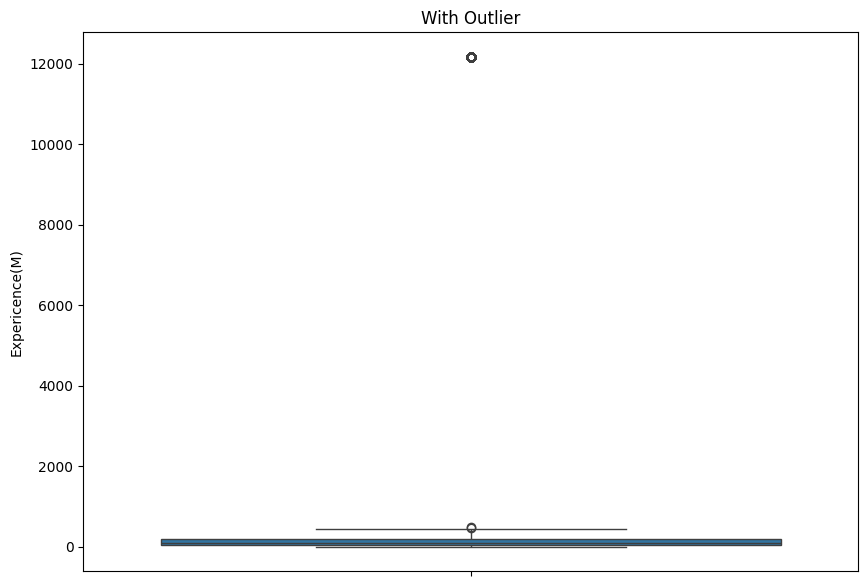

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

num_col_for_boxplot = df.select_dtypes(exclude = 'object').columns

for col in num_col_for_boxplot:
    plt.figure(figsize = (10, 7))
    sns.boxplot(df[col])
    plt.title('With Outlier')
plt.show()

In [ ]:
import numpy as np

Q1 = df['Family_Members'].quantile(0.25)
Q3 = df['Family_Members'].quantile(0.90)

IQR = Q3 - Q1
upper = Q3 + 1.5*IQR
lower = Q1 - 1.5*IQR

df.loc[(df['Family_Members'] > upper), 'Family_Members'] = np.nan
df

,Car_Owner,Propert_Owner,Type_Income,Housing_type,Family_Members,label,Monthly_Income,Age,Expericence(M)
0,Y,Y,Pensioner,House / apartment,2.0,1,15000.0,52.0,12174
1,Y,N,Commercial associate,House / apartment,2.0,1,26250.0,38.0,20
2,Y,N,Commercial associate,House / apartment,2.0,1,26250.0,NaN,20
3,Y,N,Commercial associate,House / apartment,2.0,1,NaN,38.0,20
4,Y,N,Commercial associate,House / apartment,2.0,1,26250.0,38.0,20
...,...,...,...,...,...,...,...,...,...
1543,N,Y,Commercial associate,House / apartment,2.0,0,NaN,33.0,73
1544,N,N,Commercial associate,House / apartment,1.0,0,18750.0,29.0,41
1545,Y,Y,Working,House / apartment,4.0,0,15000.0,37.0,83
1546,Y,N,Working,House / apartment,2.0,0,22500.0,42.0,22


In [ ]:
Q1 = df['Monthly_Income'].quantile(0.25)
Q3 = df['Monthly_Income'].quantile(0.75)

IQR = Q3 - Q1
upper = Q3 + 1.5*IQR
lower = Q1 - 1.5*IQR

df.loc[(df['Monthly_Income'] > upper), 'Monthly_Income'] = np.nan
df

,Car_Owner,Propert_Owner,Type_Income,Housing_type,Family_Members,label,Monthly_Income,Age,Expericence(M)
0,Y,Y,Pensioner,House / apartment,2.0,1,15000.0,52.0,12174
1,Y,N,Commercial associate,House / apartment,2.0,1,26250.0,38.0,20
2,Y,N,Commercial associate,House / apartment,2.0,1,26250.0,NaN,20
3,Y,N,Commercial associate,House / apartment,2.0,1,NaN,38.0,20
4,Y,N,Commercial associate,House / apartment,2.0,1,26250.0,38.0,20
...,...,...,...,...,...,...,...,...,...
1543,N,Y,Commercial associate,House / apartment,2.0,0,NaN,33.0,73
1544,N,N,Commercial associate,House / apartment,1.0,0,18750.0,29.0,41
1545,Y,Y,Working,House / apartment,4.0,0,15000.0,37.0,83
1546,Y,N,Working,House / apartment,2.0,0,22500.0,42.0,22


In [ ]:
df[df['Expericence(M)'] > 10000]

,Car_Owner,Propert_Owner,Type_Income,Housing_type,Family_Members,label,Monthly_Income,Age,Expericence(M)
0,Y,Y,Pensioner,House / apartment,2.0,1,15000.0,52.0,12174
7,N,N,Pensioner,House / apartment,2.0,1,15000.0,61.0,12174
26,N,Y,Pensioner,House / apartment,2.0,1,9375.0,60.0,12174
27,N,Y,Pensioner,House / apartment,2.0,1,NaN,60.0,12174
31,N,Y,Pensioner,House / apartment,2.0,1,9375.0,60.0,12174
...,...,...,...,...,...,...,...,...,...
1509,Y,Y,Pensioner,House / apartment,1.0,0,13125.0,56.0,12174
1511,N,Y,Pensioner,House / apartment,1.0,0,18000.0,56.0,12174
1514,N,N,Pensioner,Municipal apartment,1.0,0,5812.5,61.0,12174
1525,Y,Y,Pensioner,House / apartment,2.0,0,14625.0,61.0,12174


In [ ]:
Q1 = df['Expericence(M)'].quantile(0.25)
Q3 = df['Expericence(M)'].quantile(0.75)

IQR = Q3 - Q1
upper = Q3 + 1.5*IQR
lower = Q1 - 1.5*IQR

df.loc[(df['Expericence(M)'] > upper), 'Expericence(M)'] = np.nan
df

,Car_Owner,Propert_Owner,Type_Income,Housing_type,Family_Members,label,Monthly_Income,Age,Expericence(M)
0,Y,Y,Pensioner,House / apartment,2.0,1,15000.0,52.0,NaN
1,Y,N,Commercial associate,House / apartment,2.0,1,26250.0,38.0,20.0
2,Y,N,Commercial associate,House / apartment,2.0,1,26250.0,NaN,20.0
3,Y,N,Commercial associate,House / apartment,2.0,1,NaN,38.0,20.0
4,Y,N,Commercial associate,House / apartment,2.0,1,26250.0,38.0,20.0
...,...,...,...,...,...,...,...,...,...
1543,N,Y,Commercial associate,House / apartment,2.0,0,NaN,33.0,73.0
1544,N,N,Commercial associate,House / apartment,1.0,0,18750.0,29.0,41.0
1545,Y,Y,Working,House / apartment,4.0,0,15000.0,37.0,83.0
1546,Y,N,Working,House / apartment,2.0,0,22500.0,42.0,22.0


In [ ]:
df.describe()

,Family_Members,label,Monthly_Income,Age,Expericence(M)
count,1531.000000,1548.000000,1452.000000,1526.000000,1285.000000
mean,2.122796,0.113049,14549.097366,44.436435,88.754086
std,0.842853,0.316755,5999.782828,11.585840,78.493706
min,1.000000,0.000000,2812.500000,22.000000,3.000000
25%,2.000000,0.000000,9375.000000,35.000000,32.000000
50%,2.000000,0.000000,13125.000000,43.000000,66.000000
75%,3.000000,0.000000,18750.000000,54.000000,117.000000
max,4.000000,1.000000,30000.000000,69.000000,447.000000


In [ ]:
df

,Car_Owner,Propert_Owner,Type_Income,Housing_type,Family_Members,label,Monthly_Income,Age,Expericence(M)
0,Y,Y,Pensioner,House / apartment,2.0,1,15000.0,52.0,NaN
1,Y,N,Commercial associate,House / apartment,2.0,1,26250.0,38.0,20.0
2,Y,N,Commercial associate,House / apartment,2.0,1,26250.0,NaN,20.0
3,Y,N,Commercial associate,House / apartment,2.0,1,NaN,38.0,20.0
4,Y,N,Commercial associate,House / apartment,2.0,1,26250.0,38.0,20.0
...,...,...,...,...,...,...,...,...,...
1543,N,Y,Commercial associate,House / apartment,2.0,0,NaN,33.0,73.0
1544,N,N,Commercial associate,House / apartment,1.0,0,18750.0,29.0,41.0
1545,Y,Y,Working,House / apartment,4.0,0,15000.0,37.0,83.0
1546,Y,N,Working,House / apartment,2.0,0,22500.0,42.0,22.0


In [ ]:
df.isnull().sum()

,0
Car_Owner,0
Propert_Owner,0
Type_Income,0
Housing_type,0
Family_Members,17
label,0
Monthly_Income,96
Age,22
Expericence(M),263


In [ ]:
df['label'].value_counts()

,count
label,
0,1373
1,175


In [ ]:
X = df.drop('label', axis = 1)
y = df['label']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y, shuffle = True)

In [ ]:
num_col = X_train.select_dtypes(include = np.number).columns
cat_col = X_train.select_dtypes(exclude = np.number).columns

In [ ]:
print(num_col, cat_col)

Index(['Family_Members', 'Monthly_Income', 'Age', 'Expericence(M)'], dtype='object') Index(['Car_Owner', 'Propert_Owner', 'Type_Income', 'Housing_type'], dtype='object')


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('one-hot', OneHotEncoder()),
])

In [ ]:
num_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [ ]:
cat_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('one-hot', OneHotEncoder())])

In [ ]:
transformer = ColumnTransformer([
    ('num', num_pipeline, num_col),
    ('cat', cat_pipeline, cat_col)
], remainder = 'passthrough')

In [ ]:
transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['Family_Members', 'Monthly_Income', 'Age', 'Expericence(M)'], dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('one-hot', OneHotEncoder())]),
                                 Index(['Car_Owner', 'Propert_Owner', 'Type_Income', 'Housing_type'], dtype='object'))])

In [ ]:
model = LogisticRegression()

full_pipeline = Pipeline([
    ('preprocessing', transformer),
    ('estimator', model)
])

In [ ]:
full_pipeline

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Family_Members', 'Monthly_Income', 'Age', 'Expericence(M)'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('one-hot',
                                                                   OneHotEncoder())]),
                                                  Index(['Car_Owner', 'Propert_Owner', 'Type_Income', 'Housing_type'], dtype='object'))])),
                ('estimator', LogisticRegression())])

In [ ]:
full_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Family_Members', 'Monthly_Income', 'Age', 'Expericence(M)'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('one-hot',
                                                                   OneHotEncoder())]),
                                                  Index(['Car_Owner', 'Propert_Owner', 'Type_Income', 'Housing_type'], dtype='object'))])),
                ('estimator', LogisticRegression())])

In [ ]:
full_pipeline.score(X_test, y_test)

0.8870967741935484